In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

In [2]:
data_dir = Path("../data/raw")

X = pd.read_csv(
    data_dir / "secom.data",
    sep=r"\s+",
    header=None,
    na_values="NaN"
)

y = pd.read_csv(
    data_dir / "secom_labels.data",
    sep=r"\s+",
    header=None
)

missing_ratio = X.isna().mean()
high_missing_features = missing_ratio[missing_ratio >= 0.5].index

X_reduced = X.drop(columns=high_missing_features)
X_clean = X_reduced.fillna(X_reduced.median())

feature_variance = X_clean.var()
zero_variance_features = feature_variance[feature_variance == 0].index

X_clean = X_clean.drop(columns=zero_variance_features)

scaler = StandardScaler()

X_scaled_array = scaler.fit_transform(X_clean)

X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=X_clean.columns,
    index=X_clean.index
)

print("X_clean shape:", X_clean.shape)
print("X_scaled shape:", X_scaled.shape)
print("y shape:", y.shape)

X_clean shape: (1567, 446)
X_scaled shape: (1567, 446)
y shape: (1567, 2)


In [3]:
spc_features = [59, 103, 510, 348, 431, 434, 430, 21, 435, 28]

spc_signal_table = pd.DataFrame(index=X_clean.index)

for feature in spc_features:
    values = X_clean[feature]

    cl = values.mean()
    std = values.std()
    ucl = cl + 3 * std
    lcl = cl - 3 * std

    spc_signal_table[feature] = (values > ucl) | (values < lcl)

spc_alert_count = spc_signal_table.sum(axis=1)
spc_alert = spc_alert_count >= 1

print("SPC alert sample 수:", spc_alert.sum())
print("SPC non-alert sample 수:", (~spc_alert).sum())

print("\nSPC alert label 분포:")
print(y.loc[spc_alert, 0].value_counts())

SPC alert sample 수: 92
SPC non-alert sample 수: 1475

SPC alert label 분포:
0
-1    73
 1    19
Name: count, dtype: int64


In [4]:
fail_ratio = (y[0] == 1).mean()

iso_forest = IsolationForest(
    contamination=fail_ratio,
    random_state=42,
)

iso_forest.fit(X_scaled)

anomaly_score = iso_forest.decision_function(X_scaled)

ml_result = pd.DataFrame({
    "label": y[0],
    "timestamp": y[1],
    "anomaly_score": anomaly_score,
})

ml_cutoff = ml_result["anomaly_score"].quantile(0.05)
ml_alert = ml_result["anomaly_score"] <= ml_cutoff

print("ML alert cutoff:", ml_cutoff)
print("ML alert sample 수:", ml_alert.sum())
print("ML non-alert sample 수:", (~ml_alert).sum())

print("\nML alert label 분포:")
print(y.loc[ml_alert, 0].value_counts())

ML alert cutoff: -0.004132660323191788
ML alert sample 수: 79
ML non-alert sample 수: 1488

ML alert label 분포:
0
-1    68
 1    11
Name: count, dtype: int64


In [5]:
overlap_summary = pd.DataFrame({
    "label": y[0],
    "timestamp": y[1],
    "spc_alert": spc_alert,
    "ml_alert": ml_alert,
})

def assign_overlap_group(row):
    if row["spc_alert"] and row["ml_alert"]:
        return "Both"
    elif row["spc_alert"] and not row["ml_alert"]:
        return "SPC only"
    elif not row["spc_alert"] and row["ml_alert"]:
        return "ML only"
    else:
        return "No alert"

overlap_summary["group"] = overlap_summary.apply(assign_overlap_group, axis=1)

print("Overlap group count:")
print(overlap_summary["group"].value_counts())

print("\nOverlap group별 fail 비율:")
print(overlap_summary.groupby("group")["label"].apply(lambda s: (s == 1).mean()))

Overlap group count:
group
No alert    1429
SPC only      59
ML only       46
Both          33
Name: count, dtype: int64

Overlap group별 fail 비율:
group
Both        0.242424
ML only     0.065217
No alert    0.057383
SPC only    0.186441
Name: label, dtype: float64


In [6]:
overlap_group_summary = (
    overlap_summary
    .groupby("group")
    .agg(
        total_samples=("label", "count"),
        fail_samples=("label", lambda s: (s == 1).sum()),
        pass_samples=("label", lambda s: (s == -1).sum()),
        fail_ratio=("label", lambda s: (s == 1).mean()),
    )
    .reset_index()
)

overlap_group_summary["fail_capture_rate"] = (
    overlap_group_summary["fail_samples"] / (y[0] == 1).sum()
)

overlap_group_summary["pass_share"] = (
    overlap_group_summary["pass_samples"] / (y[0] == -1).sum()
)

print(overlap_group_summary)

      group  total_samples  fail_samples  pass_samples  fail_ratio  \
0      Both             33             8            25    0.242424   
1   ML only             46             3            43    0.065217   
2  No alert           1429            82          1347    0.057383   
3  SPC only             59            11            48    0.186441   

   fail_capture_rate  pass_share  
0           0.076923    0.017088  
1           0.028846    0.029392  
2           0.788462    0.920711  
3           0.105769    0.032809  


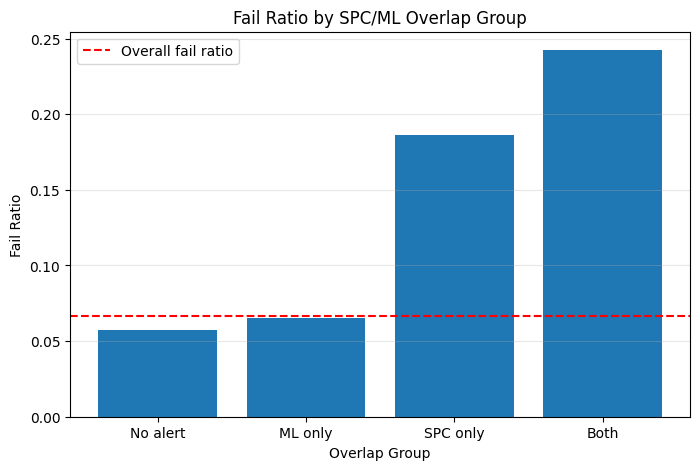

In [7]:
plot_df = overlap_group_summary.copy()

group_order = ["No alert", "ML only", "SPC only", "Both"]
plot_df["group"] = pd.Categorical(
    plot_df["group"],
    categories=group_order,
    ordered=True,
)
plot_df = plot_df.sort_values("group")

plt.figure(figsize=(8, 5))

plt.bar(
    plot_df["group"],
    plot_df["fail_ratio"],
)

plt.axhline(
    (y[0] == 1).mean(),
    color="red",
    linestyle="--",
    label="Overall fail ratio"
)

plt.title("Fail Ratio by SPC/ML Overlap Group")
plt.xlabel("Overlap Group")
plt.ylabel("Fail Ratio")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

In [8]:
risk_level_map = {
    "No alert": "Normal",
    "ML only": "Watch",
    "SPC only": "Warning",
    "Both": "High risk",
}

overlap_summary["risk_level"] = overlap_summary["group"].map(risk_level_map)

risk_summary = (
    overlap_summary
    .groupby("risk_level")
    .agg(
        total_samples=("label", "count"),
        fail_samples=("label", lambda s: (s == 1).sum()),
        pass_samples=("label", lambda s: (s == -1).sum()),
        fail_ratio=("label", lambda s: (s == 1).mean()),
    )
    .reset_index()
)

risk_order = ["Normal", "Watch", "Warning", "High risk"]
risk_summary["risk_level"] = pd.Categorical(
    risk_summary["risk_level"],
    categories=risk_order,
    ordered=True,
)
risk_summary = risk_summary.sort_values("risk_level")

print(risk_summary)

  risk_level  total_samples  fail_samples  pass_samples  fail_ratio
1     Normal           1429            82          1347    0.057383
3      Watch             46             3            43    0.065217
2    Warning             59            11            48    0.186441
0  High risk             33             8            25    0.242424


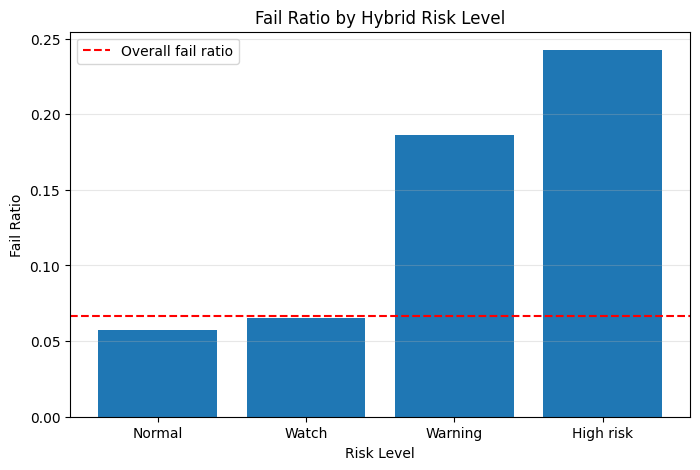

In [9]:
plt.figure(figsize=(8, 5))

plt.bar(
    risk_summary["risk_level"].astype(str),
    risk_summary["fail_ratio"],
)

plt.axhline(
    (y[0] == 1).mean(),
    color="red",
    linestyle="--",
    label="Overall fail ratio",
)

plt.title("Fail Ratio by Hybrid Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Fail Ratio")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

## SPC and ML Overlap Analysis Summary

This notebook compared SPC baseline alerts and Isolation Forest ML alerts.

### Alert Definitions

SPC alert was defined as:

- Top 10 SPC candidate features were checked.
- If a sample had at least one feature outside the control limits, it was marked as SPC alert.
- Threshold: `SPC alert count >= 1`

ML alert was defined as:

- Isolation Forest anomaly score was calculated.
- Samples in the bottom 5% anomaly score were marked as ML alert.

### Overlap Groups

Samples were divided into four groups:

| Group | Meaning |
|---|---|
| No alert | Neither SPC nor ML alert |
| ML only | ML alert only |
| SPC only | SPC alert only |
| Both | Both SPC and ML alert |

### Overlap Result

| Group | Total Samples | Fail Samples | Pass Samples | Fail Ratio |
|---|---:|---:|---:|---:|
| No alert | 1,429 | 82 | 1,347 | 5.74% |
| ML only | 46 | 3 | 43 | 6.52% |
| SPC only | 59 | 11 | 48 | 18.64% |
| Both | 33 | 8 | 25 | 24.24% |

The overall fail ratio was 6.64%.

### Interpretation

The `Both` group had the highest fail ratio at 24.24%, which is about 3.6 times higher than the overall fail ratio.

The `SPC only` group also showed a high fail ratio at 18.64%.

The `ML only` group had a fail ratio of 6.52%, which was close to the overall fail ratio.

This suggests that SPC alerts were more strongly related to fail risk than ML-only alerts under the current model setting.

### Hybrid Risk Rule

Based on the overlap result, a simple hybrid risk level was defined:

| Risk Level | Definition |
|---|---|
| Normal | No alert |
| Watch | ML only |
| Warning | SPC only |
| High risk | Both SPC and ML alert |

### Hybrid Risk Result

| Risk Level | Total Samples | Fail Samples | Pass Samples | Fail Ratio |
|---|---:|---:|---:|---:|
| Normal | 1,429 | 82 | 1,347 | 5.74% |
| Watch | 46 | 3 | 43 | 6.52% |
| Warning | 59 | 11 | 48 | 18.64% |
| High risk | 33 | 8 | 25 | 24.24% |

### Conclusion

The hybrid risk rule showed that fail ratio increased as the risk level increased.

The current result suggests:

- SPC alert is a strong signal for fail-risk sample selection.
- Isolation Forest alone was weaker than SPC under the current setting.
- However, ML alert can still be useful as a supporting signal when it overlaps with SPC alert.
- Samples detected by both SPC and ML can be treated as high-risk candidates.

This overlap analysis provides a basis for designing a hybrid anomaly detection rule.